# Lab 1 - Boundary Counting



In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


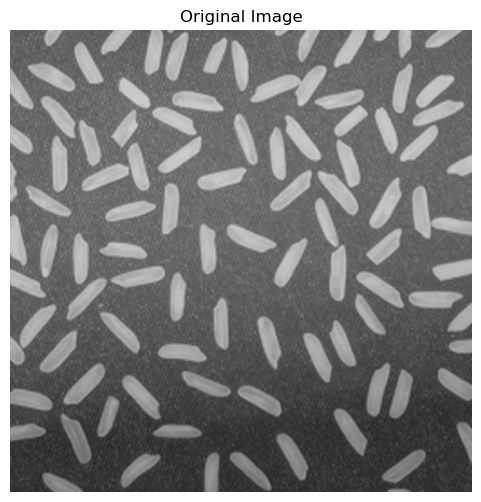

In [2]:

image_path = "rice.png"
image = cv2.imread(image_path)

if image is None:
    raise FileNotFoundError(f"Could not find {image_path} in the same directory.")

# Convert BGR to RGB for display
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 6))
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()


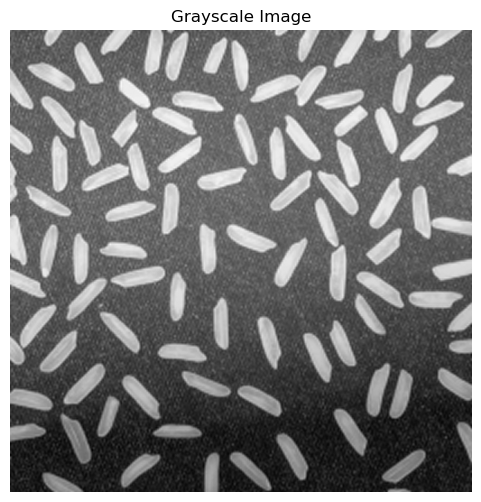

In [3]:
# Step 1: Convert to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(6, 6))
plt.imshow(gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()


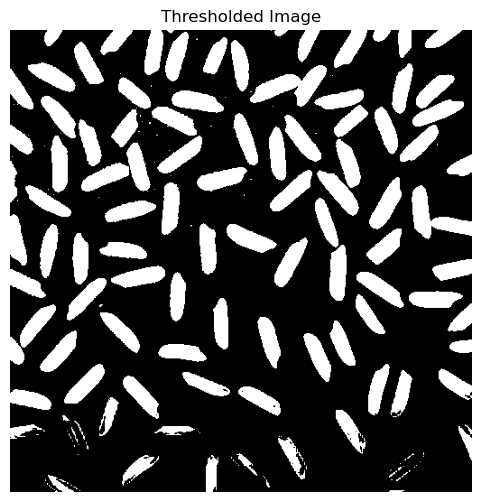

In [4]:
# Step 2: Apply threshold
# Otsu's threshold automatically selects a threshold value
_, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

plt.figure(figsize=(6, 6))
plt.imshow(thresh, cmap="gray")
plt.title("Thresholded Image")
plt.axis("off")
plt.show()


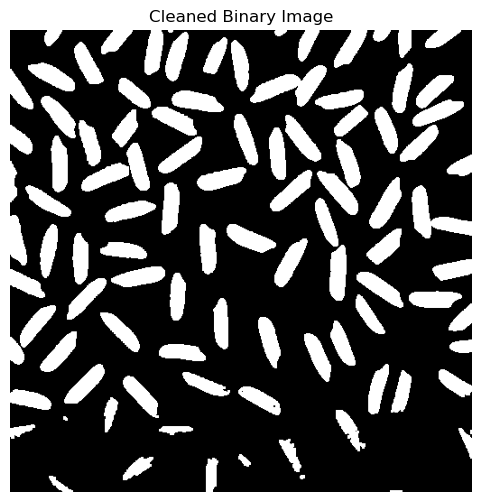

In [ ]:
kernel = np.ones((3, 3), np.uint8)
clean = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=1)

plt.figure(figsize=(6, 6))
plt.imshow(clean, cmap="gray")
plt.title("Cleaned Binary Image")
plt.axis("off")
plt.show()


In [ ]:

contours, _ = cv2.findContours(clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

count = len(contours)
print("Number of detected boundaries (rice grains):", count)


Number of detected boundaries (rice grains): 100


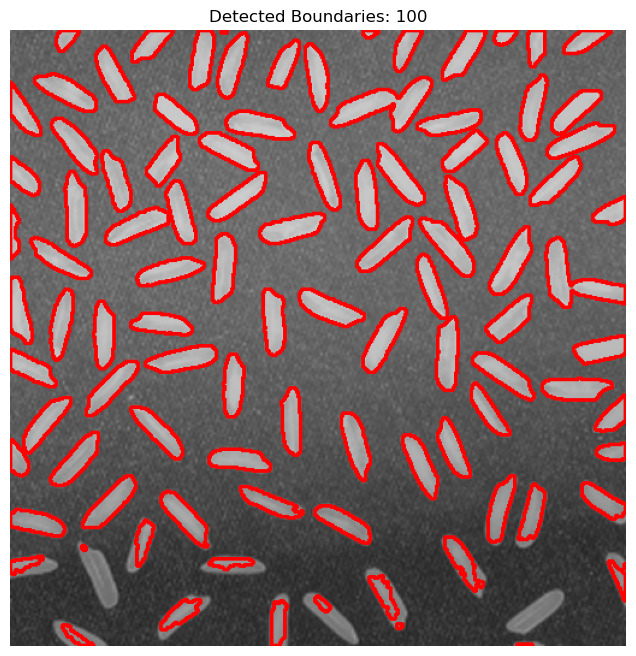

In [ ]:

output = image_rgb.copy()
cv2.drawContours(output, contours, -1, (255, 0, 0), 2)

plt.figure(figsize=(8, 8))
plt.imshow(output)
plt.title(f"Detected Boundaries: {count}")
plt.axis("off")
plt.show()
